# AI-Powered Employee Attrition Prediction System using Machine Learning

## Dataset: IBM HR Analytics Employee Attrition

## Phase 1 : Dataset Loading

Author : Aman Gupta

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Display all columns
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [12]:
# Load Dataset

df = pd.read_csv("Employee_Attrition_Prediction\dataset\employee_attrition.csv")

print("Dataset Loaded Successfully")

<>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\AMAN GUPTA\AppData\Local\Temp\ipykernel_33312\1566665643.py:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df = pd.read_csv("Employee_Attrition_Prediction\dataset\employee_attrition.csv")


Dataset Loaded Successfully


In [13]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [14]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,3,Male,41,4,2,Laboratory Technician,4,Married,2571,12290,4,Y,No,17,3,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,4,Male,42,2,3,Healthcare Representative,1,Married,9991,21457,4,Y,No,15,3,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,2,Male,87,4,2,Manufacturing Director,2,Married,6142,5174,1,Y,Yes,20,4,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,4,Male,63,2,2,Sales Executive,2,Married,5390,13243,2,Y,No,14,3,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,2,Male,82,4,2,Laboratory Technician,3,Married,4404,10228,2,Y,No,12,3,1,80,0,6,3,4,4,3,1,2


In [15]:
print("Rows and Columns : ", df.shape)

Rows and Columns :  (1470, 35)


In [16]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [18]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [19]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

# Phase 2 : Data Cleaning

In [20]:
# Check Duplicate Records

duplicates = df.duplicated().sum()

print("Total Duplicate Records :", duplicates)

Total Duplicate Records : 0


In [21]:
# Remove Duplicate Values

df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates :", df.shape)

Dataset Shape After Removing Duplicates : (1470, 35)


In [22]:
# Check Missing Values

missing_values = df.isnull().sum()

print(missing_values)

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [ ]:
# Total Missing Values

print("Total Missing Values :", df.isnull().sum().sum())

Total Missing Values : 0


In [ ]:
# Check Data Types

df.dtypes

Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesL

In [ ]:
# Convert Categorical Data into Numeric

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

# Find all object type columns
categorical_columns = df.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='str')


C:\Users\AMAN GUPTA\AppData\Local\Temp\ipykernel_33312\1612514178.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns


In [ ]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder
import joblib
import os

# Original Dataset Load
df = pd.read_csv("Employee_Attrition_Prediction\dataset\employee_attrition.csv")

label_encoders = {}

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

os.makedirs("model", exist_ok=True)
joblib.dump(label_encoders, "Employee_Attrition_Prediction/model\label_encoders.pkl")

print("Label Encoders Saved Successfully")

<>:6: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:18: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:6: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:18: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\AMAN GUPTA\AppData\Local\Temp\ipykernel_33312\3438174518.py:6: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df = pd.read_csv("Employee_Attrition_Prediction\dataset\employee_attrition.csv")
C:\Users\AMAN GUPTA\AppData\Local\Temp\ipykernel_33312\3438174518.py:18: SyntaxWarni

Label Encoders Saved Successfully


C:\Users\AMAN GUPTA\AppData\Local\Temp\ipykernel_33312\3438174518.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [ ]:
# Verify Data Types

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   int64
 2   BusinessTravel            1470 non-null   int64
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   int64
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   int64
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   int64
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [44]:
# Save Clean Dataset
df.to_csv("Employee_Attrition_Prediction\cleaned_data/clean_employee_data.csv", index=False)

print("Clean Dataset Saved Successfully")

<>:2: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:2: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
C:\Users\AMAN GUPTA\AppData\Local\Temp\ipykernel_33312\2254420676.py:2: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  df.to_csv("Employee_Attrition_Prediction\cleaned_data/clean_employee_data.csv", index=False)


Clean Dataset Saved Successfully


In [ ]:
# Final Shape

print("Final Dataset Shape :", df.shape)

Final Dataset Shape : (1470, 35)


# Phase 3 : Exploratory Data Analysis (EDA)

In [ ]:
# Load Clean Dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# Load Clean Dataset
df = pd.read_csv("Employee_Attrition_Prediction\cleaned_data\clean_employee_data.csv")

print("Clean Dataset Loaded Successfully")

<>:10: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:10: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
C:\Users\AMAN GUPTA\AppData\Local\Temp\ipykernel_33312\2897011054.py:10: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  df = pd.read_csv("Employee_Attrition_Prediction\cleaned_data\clean_employee_data.csv")


Clean Dataset Loaded Successfully


<>:10: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:10: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
C:\Users\AMAN GUPTA\AppData\Local\Temp\ipykernel_33312\1171773725.py:10: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  plt.savefig("Employee_Attrition_Prediction\images/attrition_distribution.png", dpi=300)


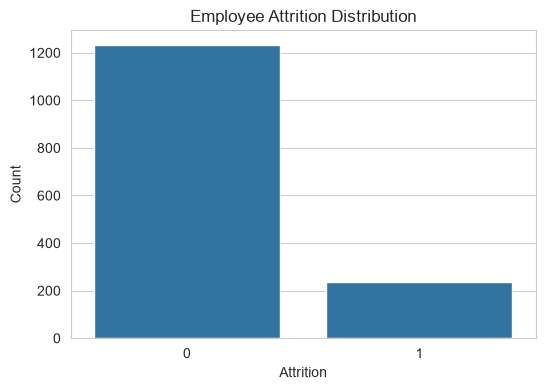

In [ ]:
# Attrition Distribution

plt.figure(figsize=(6,4))
sns.countplot(x="Attrition", data=df)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Count")

plt.savefig("Employee_Attrition_Prediction\images/attrition_distribution.png", dpi=300)
plt.show()

<>:8: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:8: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
C:\Users\AMAN GUPTA\AppData\Local\Temp\ipykernel_33312\1091042787.py:8: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  plt.savefig("Employee_Attrition_Prediction\images/age_distribution.png", dpi=300)


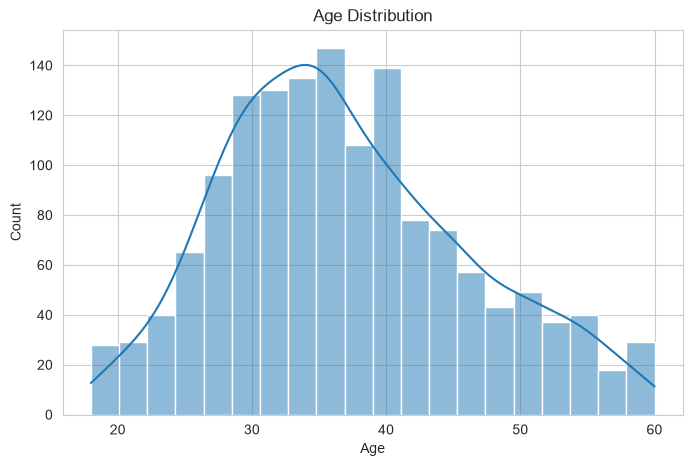

In [ ]:
# Age Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution")

plt.savefig("Employee_Attrition_Prediction\images/age_distribution.png", dpi=300)
plt.show()

<>:8: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:8: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
C:\Users\AMAN GUPTA\AppData\Local\Temp\ipykernel_33312\25170957.py:8: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  plt.savefig("Employee_Attrition_Prediction\images/monthly_income_distribution.png", dpi=300)


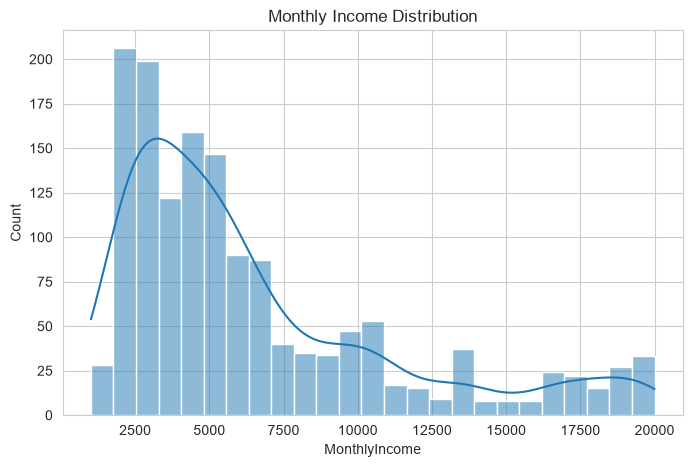

In [ ]:
# Monthly Income Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["MonthlyIncome"], bins=25, kde=True)

plt.title("Monthly Income Distribution")

plt.savefig("Employee_Attrition_Prediction\images/monthly_income_distribution.png", dpi=300)
plt.show()

<>:9: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:9: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
C:\Users\AMAN GUPTA\AppData\Local\Temp\ipykernel_33312\3561750455.py:9: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  plt.savefig("Employee_Attrition_Prediction\images/correlation_heatmap.png", dpi=300)


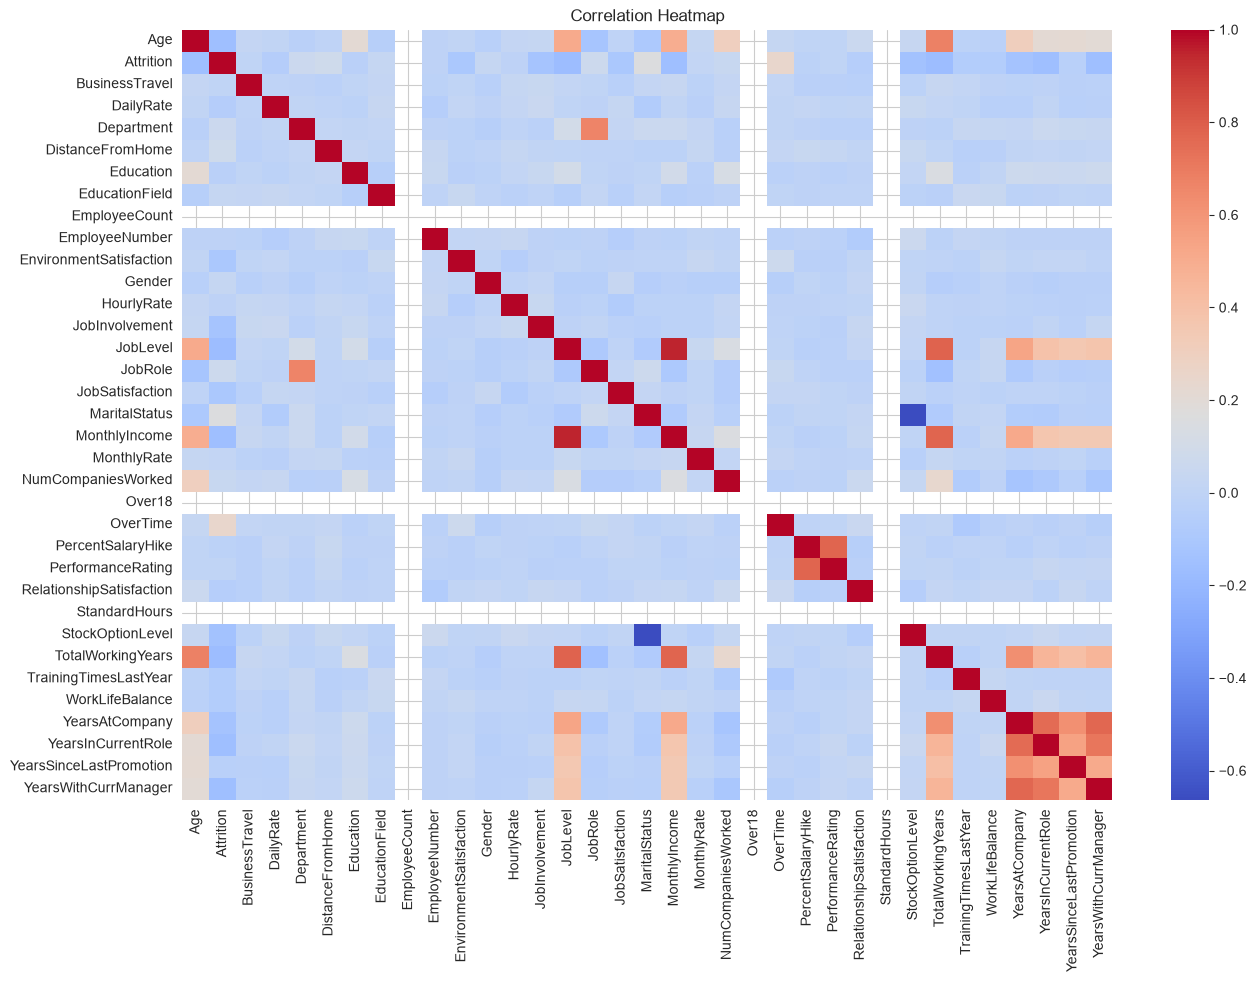

In [ ]:
# Correlation Heatmap

plt.figure(figsize=(15,10))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.savefig("Employee_Attrition_Prediction\images/correlation_heatmap.png", dpi=300)
plt.show()

<>:11: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:11: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
C:\Users\AMAN GUPTA\AppData\Local\Temp\ipykernel_33312\25090438.py:11: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  plt.savefig("Employee_Attrition_Prediction\images/gender_vs_attrition.png", dpi=300)


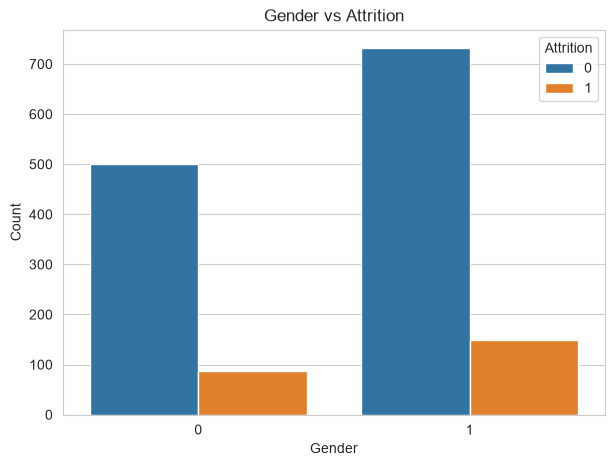

In [ ]:
# Gender vs Attrition

plt.figure(figsize=(7,5))

sns.countplot(x="Gender", hue="Attrition", data=df)

plt.title("Gender vs Attrition")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.savefig("Employee_Attrition_Prediction\images/gender_vs_attrition.png", dpi=300)

plt.show()

<>:11: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:11: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
C:\Users\AMAN GUPTA\AppData\Local\Temp\ipykernel_33312\596801134.py:11: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  plt.savefig("Employee_Attrition_Prediction\images/department_vs_attrition.png", dpi=300)


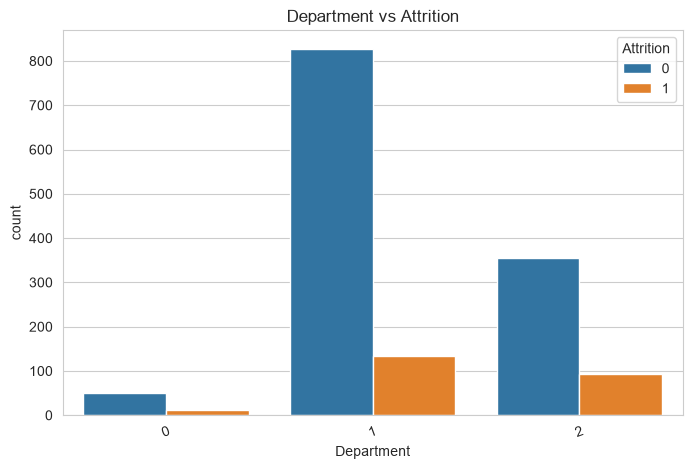

In [55]:
# Department vs Attrition

plt.figure(figsize=(8,5))

sns.countplot(x="Department", hue="Attrition", data=df)

plt.title("Department vs Attrition")

plt.xticks(rotation=20)

plt.savefig("Employee_Attrition_Prediction\images/department_vs_attrition.png", dpi=300)

plt.show()


<>:9: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:9: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
C:\Users\AMAN GUPTA\AppData\Local\Temp\ipykernel_33312\2380017466.py:9: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  plt.savefig("Employee_Attrition_Prediction\images/job_satisfaction.png", dpi=300)


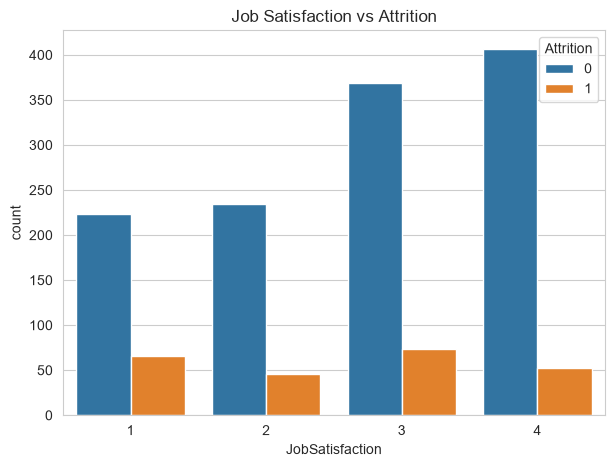

In [56]:
# Job Satisfaction

plt.figure(figsize=(7,5))

sns.countplot(x="JobSatisfaction", hue="Attrition", data=df)

plt.title("Job Satisfaction vs Attrition")

plt.savefig("Employee_Attrition_Prediction\images/job_satisfaction.png", dpi=300)

plt.show()

<>:9: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:9: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
C:\Users\AMAN GUPTA\AppData\Local\Temp\ipykernel_33312\1965305570.py:9: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  plt.savefig("Employee_Attrition_Prediction\images/overtime_vs_attrition.png", dpi=300)


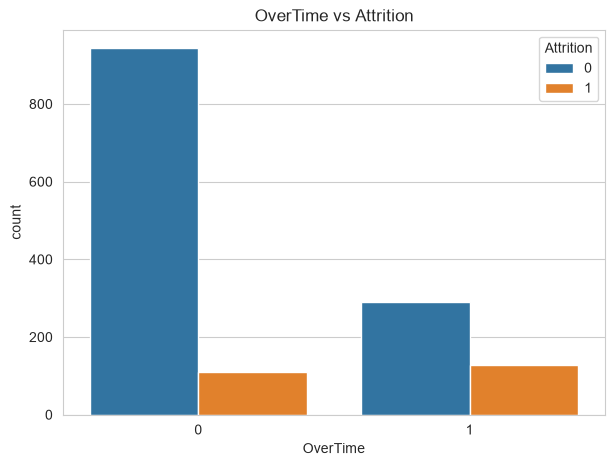

In [57]:
# Overtime vs Attrition

plt.figure(figsize=(7,5))

sns.countplot(x="OverTime", hue="Attrition", data=df)

plt.title("OverTime vs Attrition")

plt.savefig("Employee_Attrition_Prediction\images/overtime_vs_attrition.png", dpi=300)

plt.show()

<>:9: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:9: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
C:\Users\AMAN GUPTA\AppData\Local\Temp\ipykernel_33312\4272569058.py:9: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  plt.savefig("Employee_Attrition_Prediction\images/years_at_company.png", dpi=300)


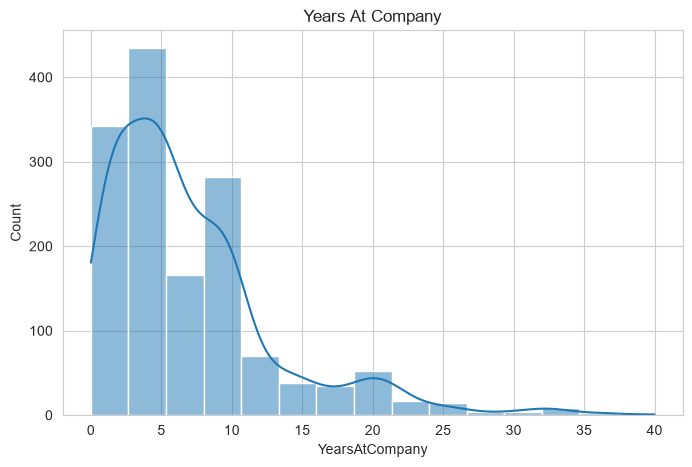

In [58]:
# Years at Company

plt.figure(figsize=(8,5))

sns.histplot(df["YearsAtCompany"], bins=15, kde=True)

plt.title("Years At Company")

plt.savefig("Employee_Attrition_Prediction\images/years_at_company.png", dpi=300)

plt.show()

<>:9: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:9: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
C:\Users\AMAN GUPTA\AppData\Local\Temp\ipykernel_33312\149123221.py:9: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  plt.savefig("Employee_Attrition_Prediction\images/education_level.png", dpi=300)


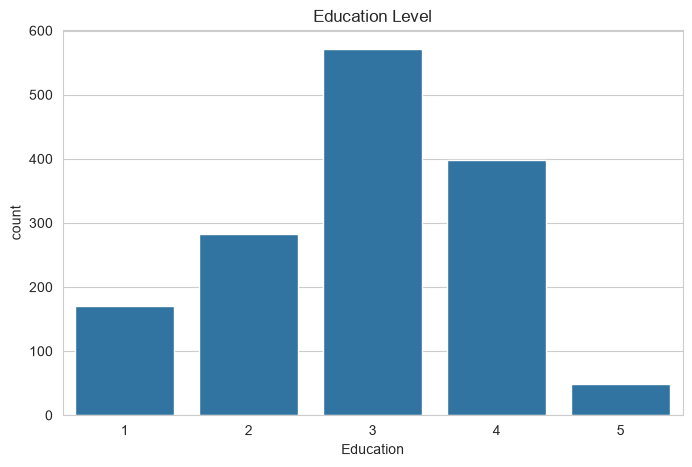

In [59]:
# Education Level

plt.figure(figsize=(8,5))

sns.countplot(x="Education", data=df)

plt.title("Education Level")

plt.savefig("Employee_Attrition_Prediction\images/education_level.png", dpi=300)

plt.show()

<>:11: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:11: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
C:\Users\AMAN GUPTA\AppData\Local\Temp\ipykernel_33312\889454216.py:11: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  plt.savefig("Employee_Attrition_Prediction\images/business_travel.png", dpi=300)


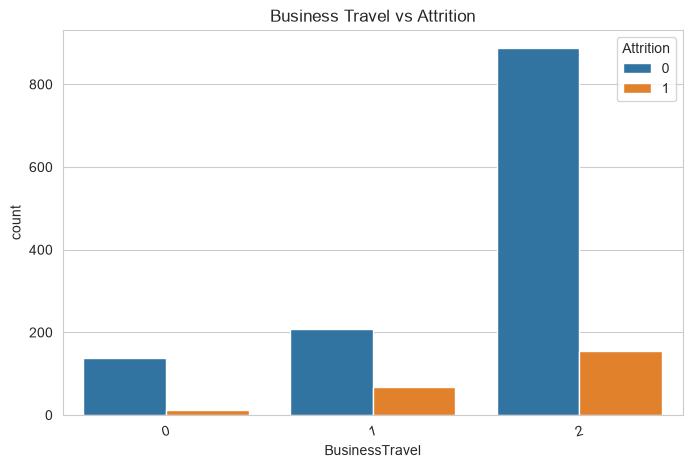

In [60]:
# Business Travel

plt.figure(figsize=(8,5))

sns.countplot(x="BusinessTravel", hue="Attrition", data=df)

plt.title("Business Travel vs Attrition")

plt.xticks(rotation=15)

plt.savefig("Employee_Attrition_Prediction\images/business_travel.png", dpi=300)

plt.show()

<>:9: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:9: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
C:\Users\AMAN GUPTA\AppData\Local\Temp\ipykernel_33312\2477665429.py:9: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  plt.savefig("Employee_Attrition_Prediction\images/job_role_distribution.png", dpi=300)


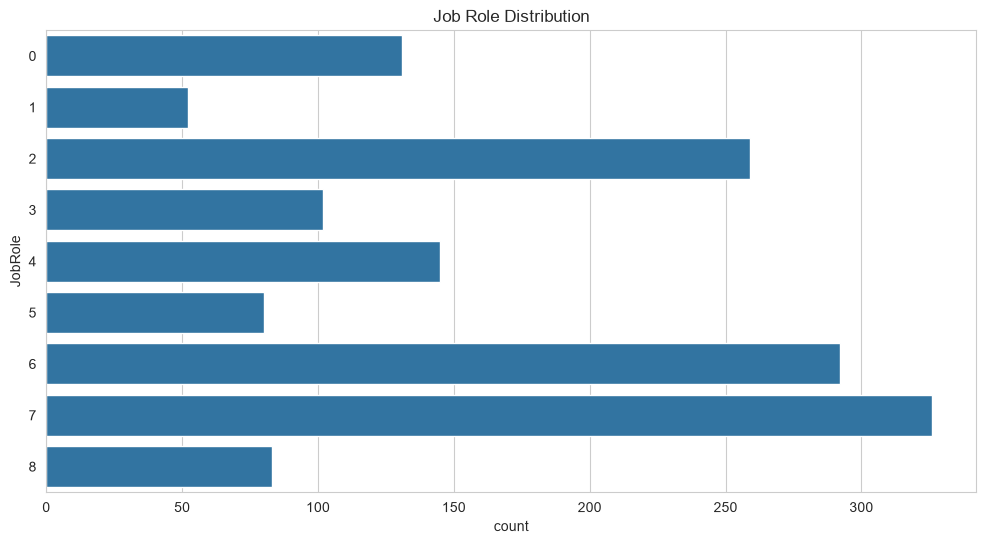

In [61]:
# Job Role Distribution

plt.figure(figsize=(12,6))

sns.countplot(y="JobRole", data=df)

plt.title("Job Role Distribution")

plt.savefig("Employee_Attrition_Prediction\images/job_role_distribution.png", dpi=300)

plt.show()

<>:9: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:9: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
C:\Users\AMAN GUPTA\AppData\Local\Temp\ipykernel_33312\1881687946.py:9: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  plt.savefig("Employee_Attrition_Prediction\images/monthly_income_boxplot.png", dpi=300)


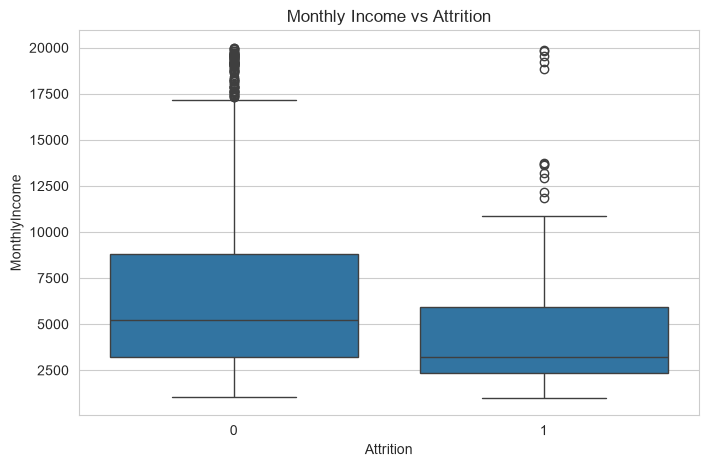

In [62]:
# Monthly Income by Attrition

plt.figure(figsize=(8,5))

sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)

plt.title("Monthly Income vs Attrition")

plt.savefig("Employee_Attrition_Prediction\images/monthly_income_boxplot.png", dpi=300)

plt.show()

<>:14: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:14: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
C:\Users\AMAN GUPTA\AppData\Local\Temp\ipykernel_33312\3318572329.py:14: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  plt.savefig("Employee_Attrition_Prediction\images/age_income_scatter.png", dpi=300)


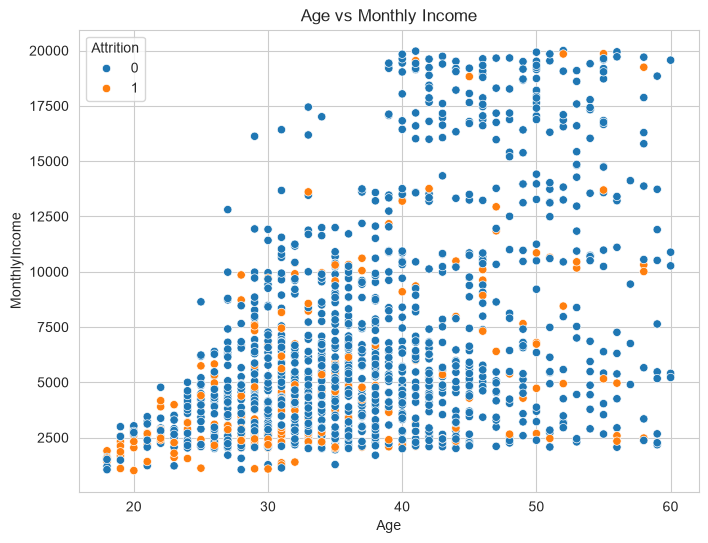

In [63]:
# Age vs Monthly Income

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Age",
    y="MonthlyIncome",
    hue="Attrition",
    data=df
)

plt.title("Age vs Monthly Income")

plt.savefig("Employee_Attrition_Prediction\images/age_income_scatter.png", dpi=300)

plt.show()

# Phase 4 : Machine Learning Model Training

In [44]:
# Import Libraries

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import pandas as pd

In [34]:
# Load Dataset

import pandas as pd

df = pd.read_csv("cleaned_data/clean_employee_data.csv")

print(df.head())

   Age  Attrition  BusinessTravel  DailyRate  Department  DistanceFromHome  \
0   41          1               2       1102           2                 1   
1   49          0               1        279           1                 8   
2   37          1               2       1373           1                 2   
3   33          0               1       1392           1                 3   
4   27          0               2        591           1                 2   

   Education  EducationField  EmployeeCount  EmployeeNumber  ...  \
0          2               1              1               1  ...   
1          1               1              1               2  ...   
2          2               4              1               4  ...   
3          4               1              1               5  ...   
4          1               3              1               7  ...   

   RelationshipSatisfaction  StandardHours  StockOptionLevel  \
0                         1             80                

In [35]:
# Features & Target

X = df.drop("Attrition", axis=1)

y = df["Attrition"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (1470, 34)
Target Shape : (1470,)


In [37]:
import os

print(os.getcwd())

d:\EI SYSTEM\Employee_Attrition_Prediction


In [39]:
import os

print(os.listdir())

['cleaned_data', 'dataset', 'Employee_Attrition.ipynb', 'gui.py', 'images', 'model', 'README.md', 'report.pdf', 'requirements.txt']


In [40]:
import os

print(os.listdir("cleaned_data"))

['clean_employee_data.csv']


In [45]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (1176, 34)
Testing Data : (294, 34)


In [46]:
# Logistic Regression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy :", lr_accuracy)

Logistic Regression Accuracy : 0.8605442176870748


C:\Users\AMAN GUPTA\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [47]:
# Decision Tree

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy :", dt_accuracy)

Decision Tree Accuracy : 0.7653061224489796


In [48]:
# Random Forest

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy :", rf_accuracy)

Random Forest Accuracy : 0.8673469387755102


In [49]:
# Accuracy Comparison

accuracy = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]

})

accuracy

,Model,Accuracy
0,Logistic Regression,0.860544
1,Decision Tree,0.765306
2,Random Forest,0.867347


In [50]:
# Best Model

best_model = accuracy.loc[accuracy["Accuracy"].idxmax()]

print(best_model)

Model       Random Forest
Accuracy         0.867347
Name: 2, dtype: object


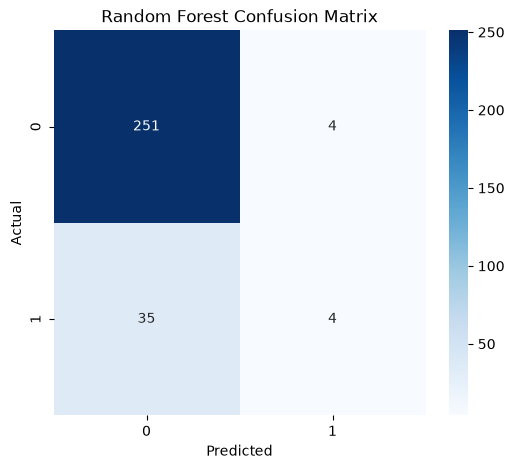

In [57]:
# Confusion Matrix

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig("images/confusion_matrix.png", dpi=300)

plt.show()

In [58]:
# Classification Report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.88      0.98      0.93       255
           1       0.50      0.10      0.17        39

    accuracy                           0.87       294
   macro avg       0.69      0.54      0.55       294
weighted avg       0.83      0.87      0.83       294



# Phase 5 : Save Machine Learning Model

In [59]:
# Import Libraries

import joblib
import os

In [60]:
# Create Model Folder

os.makedirs("Employee_Attrition_Prediction/model", exist_ok=True)

print("Model Folder Ready")

Model Folder Ready


In [61]:
# Save Random Forest Model

joblib.dump(rf, "Employee_Attrition_Prediction\model/employee_attrition_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\AMAN GUPTA\AppData\Local\Temp\ipykernel_34904\655555054.py:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  joblib.dump(rf, "Employee_Attrition_Prediction\model/employee_attrition_model.pkl")


In [62]:
# Save Feature Names

joblib.dump(X.columns.tolist(), "Employee_Attrition_Prediction\model/features.pkl")

print("Feature List Saved Successfully")

Feature List Saved Successfully


<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\AMAN GUPTA\AppData\Local\Temp\ipykernel_34904\1560835090.py:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  joblib.dump(X.columns.tolist(), "Employee_Attrition_Prediction\model/features.pkl")


In [63]:
# Save Label Encoders

from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for column in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

joblib.dump(label_encoders, "Employee_Attrition_Prediction\model/label_encoders.pkl")

print("Label Encoders Saved Successfully")

Label Encoders Saved Successfully


<>:12: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:12: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\AMAN GUPTA\AppData\Local\Temp\ipykernel_34904\3981373457.py:12: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  joblib.dump(label_encoders, "Employee_Attrition_Prediction\model/label_encoders.pkl")


In [64]:
# Test Model Load

loaded_model = joblib.load("Employee_Attrition_Prediction\model/employee_attrition_model.pkl")

print("Model Loaded Successfully")
print(type(loaded_model))

<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\AMAN GUPTA\AppData\Local\Temp\ipykernel_34904\2257082487.py:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  loaded_model = joblib.load("Employee_Attrition_Prediction\model/employee_attrition_model.pkl")


Model Loaded Successfully
<class 'sklearn.ensemble._forest.RandomForestClassifier'>


# Phase 6 – GUI (Python CustomTkinter)

In [ ]:
pip install customtkinter pillow

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/2 [darkdetect]
   ---------------------------------------- 0/2 [darkdetect]
   -------------------- ------------------- 1/2 [customtkinter]
   -------------------- ------------------- 1/2 [customtkinter]
   -------------------- ------------------- 1/2 [customtkinter]
   -------------------- ------------------- 1/2 [customtkinter]
   -------------------- ------------------- 1/2 [customtkinter]
   -------------------- ------------------- 1/2 [customtkinter]
   -------------------- ------------------- 1/2 [customtkinter]
   -------------------- ------------------- 1/2 [customtkinter]
   -------------------- ------------------- 1/2 [customtkinter]
   -------------------- ------------------- 1/2 [customtkinter]
   ---------------------------------------- 2/2 [customtkinter]

Note: you may need to restart the kernel to use updated packages.


# Updated Phase 4 – Retrain Model with Important Features

In [ ]:
# Total Features

import joblib

features = joblib.load("model/features.pkl")

print(features)
print("\nTotal Features:", len(features))

['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Total Features: 34


In [2]:
import joblib

features = joblib.load("model/features.pkl")

for i, feature in enumerate(features, start=1):
    print(f"{i}. {feature}")

1. Age
2. BusinessTravel
3. DailyRate
4. Department
5. DistanceFromHome
6. Education
7. EducationField
8. EmployeeCount
9. EmployeeNumber
10. EnvironmentSatisfaction
11. Gender
12. HourlyRate
13. JobInvolvement
14. JobLevel
15. JobRole
16. JobSatisfaction
17. MaritalStatus
18. MonthlyIncome
19. MonthlyRate
20. NumCompaniesWorked
21. Over18
22. OverTime
23. PercentSalaryHike
24. PerformanceRating
25. RelationshipSatisfaction
26. StandardHours
27. StockOptionLevel
28. TotalWorkingYears
29. TrainingTimesLastYear
30. WorkLifeBalance
31. YearsAtCompany
32. YearsInCurrentRole
33. YearsSinceLastPromotion
34. YearsWithCurrManager


In [65]:
# Import Libraries

import pandas as pd
import joblib

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [66]:
# Reload Clean Dataset

df = pd.read_csv("cleaned_data/clean_employee_data.csv")

print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,7,...,4,80,1,6,3,3,2,2,2,2


In [67]:
# Select Important Features

selected_features = [

    "Age",
    "BusinessTravel",
    "Department",
    "DistanceFromHome",
    "Education",
    "EducationField",
    "EnvironmentSatisfaction",
    "Gender",
    "JobInvolvement",
    "JobLevel",
    "JobRole",
    "JobSatisfaction",
    "MaritalStatus",
    "MonthlyIncome",
    "NumCompaniesWorked",
    "OverTime",
    "PercentSalaryHike",
    "RelationshipSatisfaction",
    "StockOptionLevel",
    "TotalWorkingYears",
    "TrainingTimesLastYear",
    "WorkLifeBalance",
    "YearsAtCompany"

]

In [68]:
# Features & Target

X = df[selected_features]

y = df["Attrition"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (1470, 23)
Target Shape : (1470,)


In [69]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42

)

print(X_train.shape)
print(X_test.shape)

(1176, 23)
(294, 23)


In [70]:
# Train Random Forest Model

rf = RandomForestClassifier(

    n_estimators=100,

    random_state=42

)

rf.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [72]:
# Prediction

prediction = rf.predict(X_test)

In [73]:
# Accuracy

accuracy = accuracy_score(y_test, prediction)

print("Accuracy :", round(accuracy * 100, 2), "%")

Accuracy : 87.76 %


In [74]:
# Classification Report

print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.71      0.13      0.22        39

    accuracy                           0.88       294
   macro avg       0.80      0.56      0.58       294
weighted avg       0.86      0.88      0.84       294



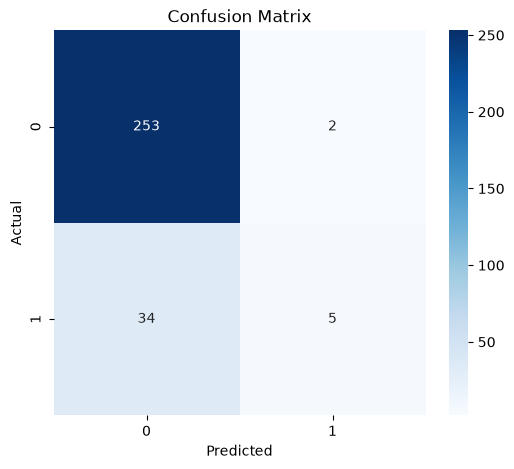

In [75]:
# Confusion Matrix

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, prediction)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [76]:
# Save Updated Model

joblib.dump(
    rf,
    "model/employee_attrition_model.pkl"
)

joblib.dump(
    selected_features,
    "model/features.pkl"
)

print("Updated Model Saved Successfully")

Updated Model Saved Successfully
